DATA SOURCE: https://apps.fs.usda.gov/fia/datamart/datamart.html

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

# for Vermont State (VT)
df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/VT_TREE.csv')

/var/folders/b6/ksn6tdwn1jb73y3kyvv9cbw40000gn/T/ipykernel_6227/155990880.py:6: DtypeWarning: Columns (0: P2A_GRM_FLG) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/VT_TREE.csv')


In [3]:
YEAR = 2022
df = df[df.INVYR == YEAR]

In [4]:
print(df.groupby('DIAHTCD').size()) # how was measured
print(df.groupby('STATUSCD').size()) # died, live, broken
print(df.groupby('HTCD').size())   # metode of measurement

DIAHTCD
1    6280
dtype: int64
STATUSCD
0      50
1    4885
2    1345
dtype: int64
HTCD
1.0    3712
2.0     529
3.0    1227
dtype: int64


In [5]:
df = df[df.STATUSCD == 1] 
df = df[df.HTCD == 1] 
df = df[df.ACTUALHT == df.HT] 

In [6]:
df = df[['INVYR', 'UNITCD', 'COUNTYCD', 'PLOT', 'TREE', 'DIA', 'HT', 'SPCD']]
red_spruce = df[df.SPCD == 97] # code for red spruce

In [7]:
red_spruce = red_spruce.rename(columns = {
'INVYR': 'inventory_year', 'UNITCD': 'survey_unit',
'COUNTYCD': 'country', 'PLOT': 'plot_number',
'TREE': 'tree_number', 'DIA': 'diameter', 'HT': 'height'})

In [8]:
grouped_by_trees = red_spruce.groupby(['survey_unit', 'country', 
                                       'plot_number', 'tree_number'])

actual_measurement = red_spruce.loc[grouped_by_trees.inventory_year.idxmax()]

In [9]:
actual_measurement['height'] = actual_measurement['height']*0.3048 # feet to meters
actual_measurement['diameter'] = actual_measurement['diameter']*2.54 # inches to centemetrs

In [10]:
actual_measurement['log_height'] = np.log(actual_measurement.height)
actual_measurement['log_diameter'] = np.log(actual_measurement.diameter)
actual_measurement.head()

,inventory_year,survey_unit,country,plot_number,tree_number,diameter,height,SPCD,log_height,log_diameter
185487,2022,2,5,204,1,18.796,11.5824,97.0,2.449487,2.933644
185513,2022,2,5,204,3,19.050,12.1920,97.0,2.500780,2.947067
185489,2022,2,5,204,4,28.702,12.8016,97.0,2.549570,3.356967
185471,2022,2,5,204,5,32.258,18.2880,97.0,2.906245,3.473766
185473,2022,2,5,204,7,30.226,18.5928,97.0,2.922774,3.408702


In [11]:
red_spruce.describe()

,inventory_year,survey_unit,country,plot_number,tree_number,diameter,height,SPCD
count,404.0,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.0
mean,2022.0,2.554455,14.000000,1117.735149,16.594059,7.650743,41.495050,97.0
std,0.0,0.497642,9.415156,965.199555,14.482935,4.318909,19.765561,0.0
min,2022.0,2.000000,1.000000,17.000000,1.000000,1.000000,7.000000,97.0
25%,2022.0,2.000000,5.000000,333.000000,6.000000,5.100000,25.000000,97.0
50%,2022.0,3.000000,11.000000,872.500000,12.000000,7.000000,41.000000,97.0
75%,2022.0,3.000000,23.000000,1469.250000,22.000000,10.225000,56.000000,97.0
max,2022.0,3.000000,27.000000,3337.000000,73.000000,24.500000,87.000000,97.0


In [12]:
red_spruce.info()

<class 'pandas.DataFrame'>
Index: 404 entries, 185471 to 191693
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   inventory_year  404 non-null    int64  
 1   survey_unit     404 non-null    int64  
 2   country         404 non-null    int64  
 3   plot_number     404 non-null    int64  
 4   tree_number     404 non-null    int64  
 5   diameter        404 non-null    float64
 6   height          404 non-null    float64
 7   SPCD            404 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 44.6 KB


In [13]:
red_spruce.duplicated().sum()

np.int64(0)

<Axes: xlabel='diameter', ylabel='height'>

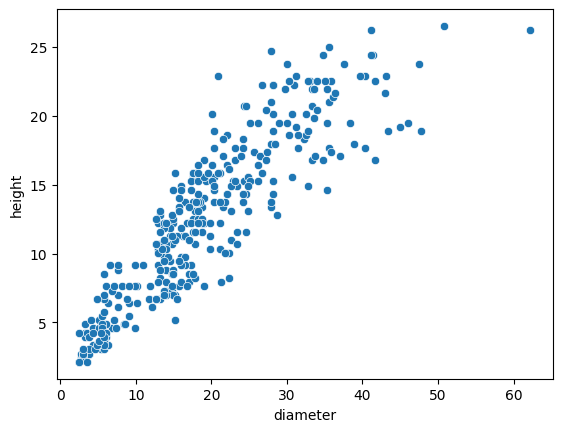

In [14]:
sns.scatterplot(x = 'diameter', y = 'height', data = actual_measurement)

<Axes: xlabel='log_diameter', ylabel='log_height'>

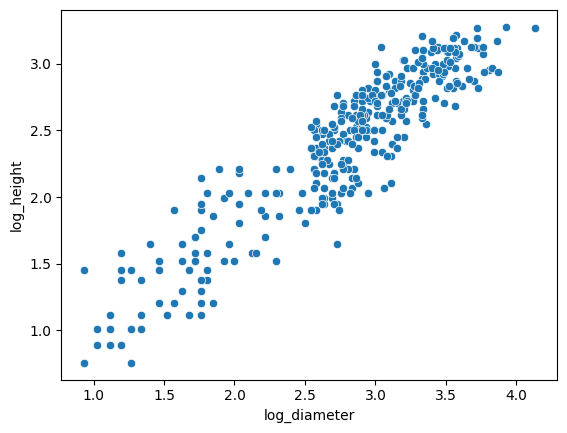

In [15]:
sns.scatterplot(x = 'log_diameter', y = 'log_height', data = actual_measurement)

In [17]:
actual_measurement.to_csv('red_spruce_2022.csv', index=False, encoding='utf-8-sig')